In [1]:
!pip install --upgrade pip -q
!pip install -qU "transformers>=4.40.0" peft datasets scikit-learn seaborn matplotlib pandas tqdm bitsandbytes accelerate
!pip install -qU --prefer-binary "bitsandbytes>=0.43.1" accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 143.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 162.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 184.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 104.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os, gc, torch, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from datasets import load_dataset
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from transformers import BitsAndBytesConfig

login(token="YOUR_HF_TOKEN_HERE")

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

def make_prompt(text: str) -> str:
    return (
        "Instruction: What is the sentiment of this news? "
        "Please choose an answer from {negative/neutral/positive}\n"
        f"Input: {text}\n"
        "Answer:"
    )

In [3]:
dataset = load_dataset("takala/financial_phrasebank", "sentences_allagree")
data = dataset["train"]
sentences = data["sentence"]

label_names = data.features["label"].names
label2id = {name: idx for idx, name in enumerate(label_names)}
id2label = {v: k for k, v in label2id.items()}
y_true = [label2id[label_names[lbl]] for lbl in data["label"]]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/8.88k [00:00<?, ?B/s]

financial_phrasebank.py:   0%|          | 0.00/6.04k [00:00<?, ?B/s]

The repository for takala/financial_phrasebank contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/takala/financial_phrasebank.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


FinancialPhraseBank-v1.0.zip:   0%|          | 0.00/682k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

In [4]:
MODELS = [

    dict(
        pretty="Finistral‑7B‑LoRA",
        base="mistralai/Mistral-7B-v0.1",
        peft="Ayansk11/Finistral-7B_lora",
    ),

    dict(
        pretty="FinGPT‑Falcon‑7B‑LoRA",
        base="tiiuae/falcon-7b",
        peft="FinGPT/fingpt-mt_falcon-7b_lora"
    ),

    dict(
        pretty="FinGPT‑Llama‑3‑8B‑LoRA",
        base="meta-llama/Meta-Llama-3-8B",
        peft="FinGPT/fingpt-mt_llama3-8b_lora"
    ),

    dict(
        pretty="FinGPT‑Bloom‑7B1‑LoRA",
        base="bigscience/bloom-7b1",
        peft="FinGPT/fingpt-mt_bloom-7b1_lora"
    ),

]

In [5]:
import re

_SENT_RE = re.compile(r"\b(negative|neutral|positive|neg|neu|pos)\b", re.I)
_map3 = {"neg": 0, "neu": 1, "pos": 2}

def extract_sentiment(text: str) -> str:
    """
    Return 'neg', 'neu', or 'pos' from a model answer string.
    If nothing is found, return 'neu' (neutral).
    """
    t = text.lower()
    if "answer:" in t:
        after = t.split("answer:", 1)[1]
        m = _SENT_RE.search(after)
        if m:
            return m.group(1)[:3]
    m = _SENT_RE.search(t)
    return m.group(1)[:3] if m else "neu"


In [6]:
def evaluate_model(base_model: str, peft_model: str | None, batch_size: int = 8):
    """Run the exact classification loop you wrote and return metrics dict."""
    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(base_model, use_auth_token=True)
    tokenizer.pad_token = tokenizer.eos_token

    quant_cfg = BitsAndBytesConfig(
        load_in_8bit=True,
        bnb_8bit_compute_dtype=torch.float16,
        bnb_8bit_use_double_quant=True,
        bnb_8bit_quant_type="nf4",
    )

    model = AutoModelForCausalLM.from_pretrained(
        base_model,
        device_map="auto",
        quantization_config=quant_cfg,
        trust_remote_code=True,
        token=True,
        torch_dtype=torch.float16,
    )


    if peft_model:
        model = PeftModel.from_pretrained(model, peft_model)
    model.eval()

    y_pred = []
    for start in tqdm(
        range(0, len(sentences), batch_size),
        desc=f"Running {peft_model or base_model}",
    ):
        batch = sentences[start : start + batch_size]
        prompts = [make_prompt(t) for t in batch]
        tokens = tokenizer(
            prompts, return_tensors="pt", padding=True, max_length=512
        ).to(model.device)

        with torch.no_grad():
            outputs = model.generate(**tokens, max_length=512)



        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        for out in decoded:
            tag = extract_sentiment(out)
            y_pred.append(_map3[tag])



    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    cls_report = classification_report(
        y_true,
        y_pred,
        target_names=["negative", "neutral", "positive"],
        output_dict=True,
        zero_division=0,
    )
    conf_mat = confusion_matrix(y_true, y_pred)

    del model, tokenizer, tokens, outputs
    torch.cuda.empty_cache()
    gc.collect()

    return {
        "accuracy": acc,
        "weighted_f1": f1,
        "report": cls_report,
        "cm": conf_mat,
    }

In [7]:
results = {}
for cfg in MODELS:
    print(f"\n💫 Evaluating {cfg['pretty']}...")
    metrics = evaluate_model(cfg["base"], cfg["peft"])
    results[cfg["pretty"]] = metrics


💫 Evaluating Finistral‑7B‑LoRA...


/usr/local/lib/python3.11/dist-packages/transformers/models/auto/tokenization_auto.py:898: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in v5 of Transformers. Please use `token` instead.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/996 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.80M [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

adapter_model.bin:   0%|          | 0.00/7.87M [00:00<?, ?B/s]

Running FinGPT/fingpt-mt_bloom-7b1_lora:   0%|          | 0/283 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:2718: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
Running FinGPT/fingpt-mt_bloom-7b1_lora: 100%|██████████| 283/283 [3:18:33<00:00, 42.10s/it]



=== Overall comparison ===


,Accuracy,Weighted F1
Finistral‑7B‑LoRA,0.9956,0.9956
FinGPT‑Llama‑3‑8B‑LoRA,0.2310,0.2112
FinGPT‑Falcon‑7B‑LoRA,0.2102,0.1713
FinGPT‑Bloom‑7B1‑LoRA,0.1312,0.0310


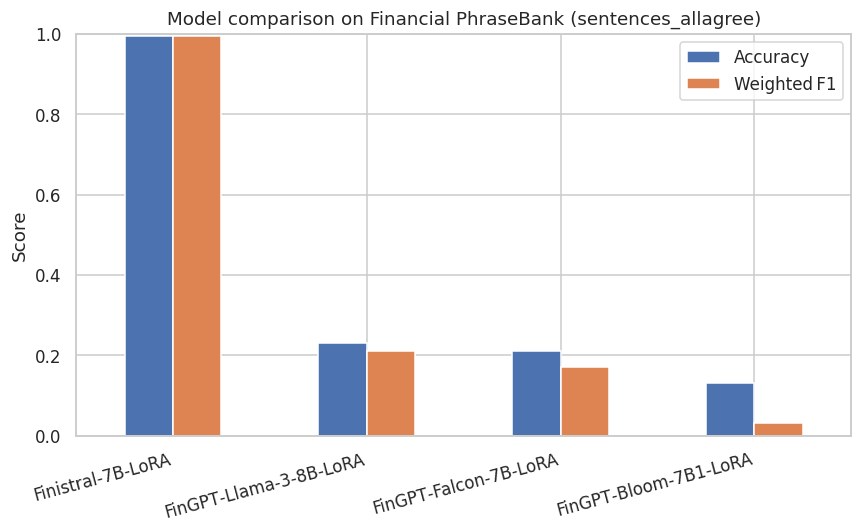

In [8]:
summary_df = pd.DataFrame.from_dict(
    {
        mname: {"Accuracy": m["accuracy"], "Weighted F1": m["weighted_f1"]}
        for mname, m in results.items()
    },
    orient="index",
).round(4).sort_values("Weighted F1", ascending=False)

print("\n=== Overall comparison ===")
display(summary_df)

ax = summary_df.plot(kind="bar", figsize=(8, 5))
plt.title("Model comparison on Financial PhraseBank (sentences_allagree)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()